# Assignment 3 — Kalman Filter Based Pair Trading (SPY vs DJIA)

This assignment is to use Kalman filter to implement the pair trading strategy of S&P 500 ETF and the Dow Jones Industrial ETF.

Please read the document (Kalman filtering case study.pdf) in Resources/Session 5 folder which discusses the Pair Trading strategy and answer the following questions.

(a). Derive the beta update equation (Kalman filter) for the pair trading strategy of the two ETFs ( which is the same format with the last equation on page 72).

(b). Code up the pair trading strategy and compare rolling regression vs Kalman filtering.

In [1]:
%matplotlib inline

from typing import Optional
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)


# Q(a) Derive the beta update equation (Kalman filter)

## The formula by using the symbols in Kalman filtering case study:

### General Kalman filter setup

$$
X_t = F X_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0, Q)
$$

$$
Z_t = H X_t + v_t, \quad v_t \sim \mathcal{N}(0, R)
$$

Prediction step:

$$
\hat{X}_{t|t-1} = F \hat{X}_{t-1}
$$

$$
P_{t|t-1} = F P_{t-1} F^\top + Q
$$

Kalman gain:

$$
K_t = P_{t|t-1} H^\top \left( H P_{t|t-1} H^\top + R \right)^{-1}
$$

Update:

$$
\hat{X}_t = \hat{X}_{t|t-1} + K_t \left( Z_t - H \hat{X}_{t|t-1} \right)
$$

$$
P_t = P_{t|t-1} + K_t H P_{t|t-1}
$$

---

### Conditional distribution result

If

$$
\begin{pmatrix}
X \\
Z
\end{pmatrix}
\sim
\mathcal{N}
\left(
\begin{pmatrix}
\mu_X \\
\mu_Z
\end{pmatrix},
\begin{pmatrix}
\Sigma_{XX} & \Sigma_{XZ} \\
\Sigma_{ZX} & \Sigma_{ZZ}
\end{pmatrix}
\right)
$$

Then

$$
\mathbb{E}[X|Z] = \mu_X + \Sigma_{XZ} \Sigma_{ZZ}^{-1} (Z - \mu_Z)
$$

$$
\mathrm{Var}(X|Z) = \Sigma_{XX} - \Sigma_{XZ} \Sigma_{ZZ}^{-1} \Sigma_{ZX}
$$

---

## Pair trading model

Measurement equation:

$$
S_{t,AU} = \beta_t S_{t,CA} + v_t, \quad v_t \sim \mathcal{N}(0, \sigma_v^2)
$$

State equation:

$$
\beta_t = \beta_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0, Q_t)
$$

Prior:

$$
\beta_{t|t-1} \sim \mathcal{N}(\hat{\beta}_{t-1}, P_{t-1})
$$

Prediction:

$$
\hat{\beta}_{t|t-1} = \hat{\beta}_{t-1}
$$

$$
P_{t|t-1} = P_{t-1} + Q_t
$$

Kalman gain:

$$
K_t = P_{t|t-1} S_{t,CA}
\left(
S_{t,CA}^2 P_{t|t-1} + \sigma_v^2
\right)^{-1}
$$

Rewrite:

$$
K_t =
\frac{P_{t|t-1} S_{t,CA}}
{S_{t,CA}^2 P_{t|t-1} + \sigma_v^2}
$$

Divide numerator and denominator by \(P_{t|t-1}\):

$$
K_t =
\frac{S_{t,CA}}
{S_{t,CA}^2 + \sigma_v^2 / P_{t|t-1}}
$$

Let

$$
\sigma^{-1} = \frac{\sigma_v^2}{P_{t|t-1}}
$$

Then

$$
K_t =
\frac{S_{t,CA}}
{S_{t,CA}^2 + \sigma^{-1}}
$$

---

## Beta update

$$
\hat{\beta}_{t|t}
=
\hat{\beta}_{t|t-1}
+
\frac{S_{t,CA}}
{S_{t,CA}^2 + \sigma^{-1}}
\left(
S_{t,AU} - S_{t,CA} \hat{\beta}_{t|t-1}
\right)
$$

---

Expand:

$$
=
\left(
1 -
\frac{S_{t,CA}^2}
{S_{t,CA}^2 + \sigma^{-1}}
\right)
\hat{\beta}_{t|t-1}
+
\frac{S_{t,CA} S_{t,AU}}
{S_{t,CA}^2 + \sigma^{-1}}
$$

---

## Interpretation

If large \( \sigma \) (large SNR):

$$
\sigma^{-1} \to 0
$$

Then

$$
\hat{\beta}_{t|t} \to \frac{S_{t,AU}}{S_{t,CA}}
$$

If small \( \sigma \) (low SNR):

$$
\sigma^{-1} \to \infty
$$

Then

$$
\hat{\beta}_{t|t} \to \hat{\beta}_{t|t-1}
$$

---

## On use case

$$
S_{t,AU} = \beta S_{t,CA} + v_t
$$

Residual:

$$
v_t = S_{t,AU} - \beta S_{t,CA}
$$

If

$$
|v_t| > \theta \sigma_v
$$

Then trade:

- Long AU, short CA  
- or short AU, long CA 


## In x-y term derivation
### 1. Pair model as a Dynamic Linear Model 

Let:
- $y_t$ = dependent, eg. SPY price at time $t$  
- $x_t$ = hedge, eg. DJIA price at time $t$ 
- $\beta_t$ = *time-varying* hedge ratio (latent state)

Use the same setup as the case study (no intercept):

**Measurement (observation) equation**
$$y_t = x_t\,\beta_t + v_t, \qquad v_t \sim \mathcal{N}(0, R)$$

**State evolution equation (random walk)**
$$\beta_t = \beta_{t-1} + w_t, \qquad w_t \sim \mathcal{N}(0, Q)$$

Here $R=\sigma_v^2$ controls measurement noise** and $Q=\sigma_w^2$ controls how fast $\beta_t$ is allowed to move.

---

### 2. Scalar Kalman recursion (closed form)

Denote:
- prior mean: $\hat\beta_{t|t-1}$
- prior variance: $P_{t|t-1}$
- posterior mean: $\hat\beta_{t|t}$
- posterior variance: $P_{t|t}$

#### Prediction step
$$\hat\beta_{t|t-1} = \hat\beta_{t-1|t-1}$$

$$P_{t|t-1} = P_{t-1|t-1} + Q$$

#### Update step
Kalman gain:
$$K_t = \frac{P_{t|t-1} x_t}{x_t^2 P_{t|t-1} + R}$$

Beta update:

$$\boxed{
\hat\beta_{t|t} = \hat\beta_{t|t-1} + K_t\,(y_t - x_t\hat\beta_{t|t-1})
}$$

Variance update:
$$P_{t|t} = (1 - K_t x_t) P_{t|t-1}$$

---

If we define the signal-to-noise ratio quantity
$$\gamma_t = \frac{P_{t|t-1}}{R}$$
then the Kalman gain can be rewritten into the same *univariate* form shown in the case study:

$$K_t = \frac{x_t}{x_t^2 + \gamma_t^{-1}}$$

so the beta update becomes
$$
\boxed{
\hat\beta_{t|t} = \hat\beta_{t|t-1} + \frac{x_t}{x_t^2 + \gamma_t^{-1}}
\left(y_t - x_t\hat\beta_{t|t-1}\right)
}
$$

This is exactly the same format as the final equation on the case study page 72, with:
- $y_t$ ↔ price of the “dependent” ETF
- $x_t$ ↔ price of the “hedge” ETF


# Q(b) Code up the pair trading strategy and compare rolling regression vs Kalman filtering.
## 1. Data Processing

In [2]:
def _find_file(candidates, folder=Path(".")):
    folder = Path(folder)
    
    lower_map = {p.name.lower(): p for p in folder.glob("*.csv")}
    
    for name in candidates:
        p = folder / name
        
        
        if p.exists():
            return p
        
        if name.lower() in lower_map:
            return lower_map[name.lower()]
        
    for p in folder.glob("*.csv"):
        
        for name in candidates:
            
            if name.lower().replace('.csv','') in p.name.lower():
                return p
            
            
    raise FileNotFoundError(f"Could not find any of {candidates} in {folder.resolve()}")

In [3]:
def load_etf_prices(folder=Path(".")):

    folder = Path(folder)
    spy_file  = _find_file(["spy.csv", "SPY.csv"], folder)
    
    djia_file = _find_file(["djia.csv", "DJIA.csv"], folder)

    def _read_one(fp):
        df = pd.read_csv(fp)
        
        df["Date"] = pd.to_datetime(df["Date"])
        
        df = df.sort_values("Date").set_index("Date")
        
        px = df["PX_LAST"].rename(fp.stem.upper())
        
        
        return px

    spy_px  = _read_one(spy_file)
    
    djia_px = _read_one(djia_file)

    merged = pd.concat([spy_px, djia_px], axis=1).dropna()
    merged.columns = ["SPY", "DJIA"]
    return merged

px = load_etf_prices(Path(".")) 


px.head(), px.tail(), px.describe() ,px.shape

(                 SPY      DJIA
 Date                          
 2000-01-03  145.4375  113.5000
 2000-01-04  139.7500  109.7656
 2000-01-05  140.0000  111.1875
 2000-01-06  137.7500  111.7500
 2000-01-07  145.7500  115.5000,
                SPY    DJIA
 Date                      
 2021-12-27  477.26  362.92
 2021-12-28  476.87  363.99
 2021-12-29  477.48  364.84
 2021-12-30  476.16  364.07
 2021-12-31  474.96  363.32,
                SPY         DJIA
 count  5536.000000  5536.000000
 mean    177.324876   155.389434
 std      85.478755    69.649834
 min      68.110000    65.440000
 25%     117.515000   105.000000
 50%     141.062500   125.585000
 75%     212.542500   181.192500
 max     477.480000   364.840000,
 (5536, 2))

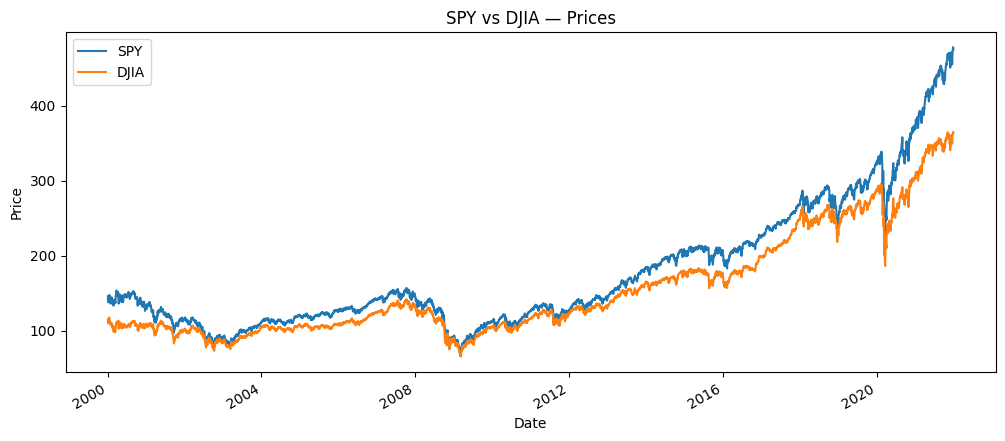

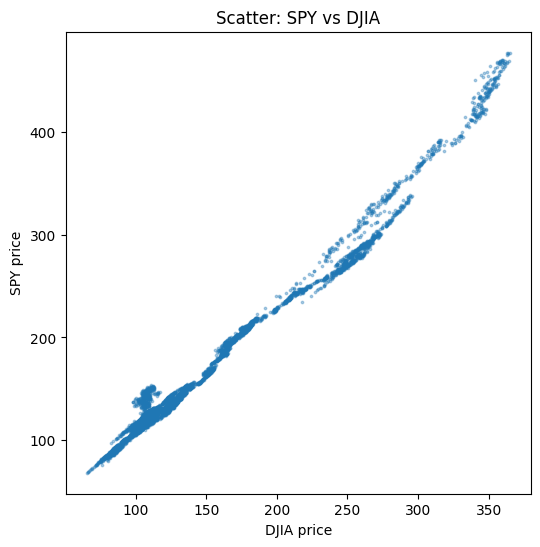

In [4]:
px.plot(title="SPY vs DJIA — Prices")
plt.ylabel("Price")
plt.show()
plt.figure(figsize=(6,6))
plt.scatter(px["DJIA"], px["SPY"], s=3, alpha=0.35)
plt.xlabel("DJIA price")
plt.ylabel("SPY price")
plt.title("Scatter: SPY vs DJIA")
plt.show()


## 2. Rolling Linear Regression

In [5]:
def rolling_beta_no_intercept(y: pd.Series, x: pd.Series, lookback: int) -> pd.Series:
    xy = (x * y).rolling(lookback).sum()
    xx = (x * x).rolling(lookback).sum()
    return xy / xx

lookback_days = 126 

log_px = np.log(px[["SPY", "DJIA"]])

beta_roll = rolling_beta_no_intercept(log_px["SPY"], log_px["DJIA"], lookback_days)

resid_roll = log_px["SPY"] - beta_roll * log_px["DJIA"]

sigma_roll = resid_roll.rolling(lookback_days).std()
beta_roll.dropna().head()

Date
2000-06-30    1.062265
2000-07-03    1.062411
2000-07-05    1.062550
2000-07-06    1.062721
2000-07-07    1.062934
dtype: float64

## 3. Kalman Filter for Time-Varying Beta

In [6]:
def kalman_beta_univariate(y: np.ndarray, x: np.ndarray, q_var: float, r_var: float,
                           beta0: Optional[float] = None, P0: float = 1.0):

    n = len(y)
    beta_path = np.zeros(n)
    P_path = np.zeros(n)
    
    innov = np.zeros(n)

    if beta0 is None:
        beta0 = (y[0] / x[0]) if x[0] != 0 else 1.0

    b = float(beta0)
    P = float(P0)

    for t in range(n):
        b_prior = b
        
        P_prior = P + q_var

        e = y[t] - x[t] * b_prior

        gamma_t = P_prior / r_var if r_var > 0 else 0.0
        
        denom = (x[t] ** 2) + (1.0 / gamma_t if gamma_t > 0 else np.inf)
        
        
        K = (x[t] / denom) if np.isfinite(denom) and denom != 0 else 0.0

        b = b_prior + K * e
        P = (1.0 - K * x[t]) * P_prior

        beta_path[t] = b
        P_path[t] = P
        innov[t] = e

    return beta_path, P_path, innov


log_px = np.log(px[["SPY", "DJIA"]])
init_win = min(lookback_days, len(log_px))


beta_init = float((log_px["SPY"].iloc[:init_win] * log_px["DJIA"].iloc[:init_win]).sum()
                  / (log_px["DJIA"].iloc[:init_win] ** 2).sum())

res0 = log_px["SPY"].iloc[:init_win] - beta_init * log_px["DJIA"].iloc[:init_win]
R_var = float(np.nanvar(res0.values)) if len(res0) > 0 else 1e-6


delta = 1e-5

q_var = float(delta)

beta_kf_arr, P_kf, innov_kf = kalman_beta_univariate(
    y=log_px["SPY"].values,
    
    
    x=log_px["DJIA"].values,
    q_var=q_var,
    r_var=R_var,
    beta0=beta_init,
    P0=1.0
)

beta_kf = pd.Series(beta_kf_arr, index=px.index, name="beta_kf")

resid_kf = log_px["SPY"] - beta_kf * log_px["DJIA"]


sigma_kf = resid_kf.rolling(lookback_days).std()

beta_kf.head(), beta_kf.tail(), beta_kf.describe()

(Date
 2000-01-03    1.052400
 2000-01-04    1.051859
 2000-01-05    1.050601
 2000-01-06    1.048192
 2000-01-07    1.048485
 Name: beta_kf, dtype: float64,
 Date
 2021-12-27    1.045952
 2021-12-28    1.045890
 2021-12-29    1.045770
 2021-12-30    1.045661
 2021-12-31    1.045572
 Name: beta_kf, dtype: float64,
 count    5536.000000
 mean        1.024317
 std         0.011612
 min         1.001154
 25%         1.015938
 50%         1.021596
 75%         1.030506
 max         1.072833
 Name: beta_kf, dtype: float64)

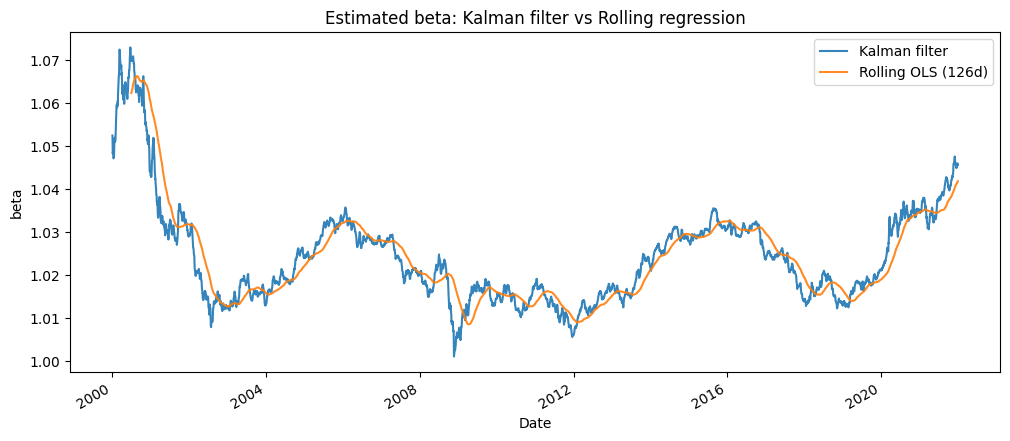

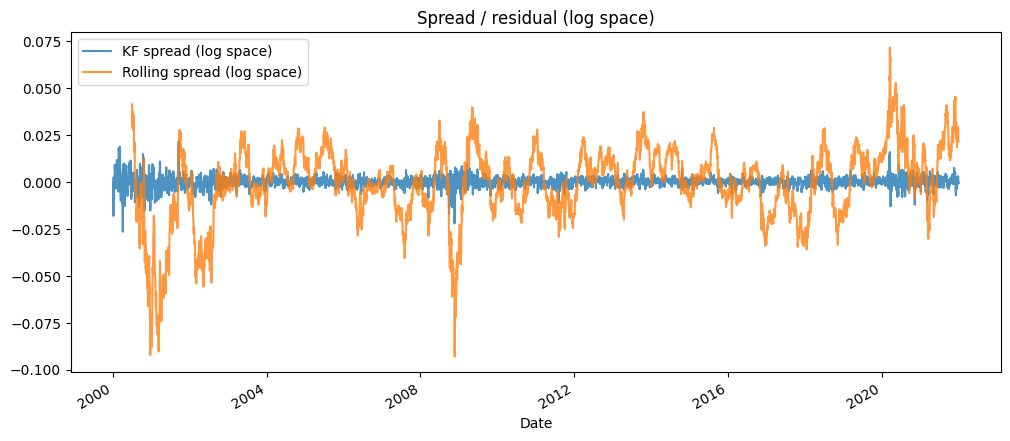

In [7]:
#Beta comparison plot (Rolling vs Kalman)
plt.figure()
beta_kf.plot(label="Kalman filter", alpha=0.9)

beta_roll.plot(label=f"Rolling OLS ({lookback_days}d)", alpha=0.9)


plt.title("Estimated beta: Kalman filter vs Rolling regression")
plt.ylabel("beta")

plt.legend()
plt.show()

plt.figure()
resid_kf.plot(label="KF spread (log space)", alpha=0.8)

resid_roll.plot(label="Rolling spread (log space)", alpha=0.8)


plt.title("Spread / residual (log space)")
plt.legend()
plt.show()

## 4. Trading Rule

In [8]:
def compute_positions(resid: pd.Series, resid_scale: pd.Series, beta: pd.Series, k: float):
    
    sig = resid_scale.replace(0, np.nan)
    z = resid / sig

    w_spy = pd.Series(0.0, index=resid.index)
    
    
    w_djia = pd.Series(0.0, index=resid.index)

    long_spy = z <= -k
    short_spy = z >= k

    gross = (1.0 + beta.abs()).replace(0, np.nan)

    w_spy[long_spy]  =  1.0 / gross[long_spy]
    
    
    w_djia[long_spy] = -beta[long_spy] / gross[long_spy]

    w_spy[short_spy]  = -1.0 / gross[short_spy]
    
    w_djia[short_spy] =  beta[short_spy] / gross[short_spy]

    pos = pd.DataFrame({"w_spy": w_spy, "w_djia": w_djia, "z": z})
    return pos


def backtest_pairs(px_df: pd.DataFrame, pos: pd.DataFrame):
    next_ret = px_df.pct_change().shift(-1)

    pnl = pos["w_spy"] * next_ret["SPY"] + pos["w_djia"] * next_ret["DJIA"]
    
    pnl = pnl.fillna(0.0)

    equity = (1.0 + pnl).cumprod()
    return pnl, equity


def perf_stats(pnl: pd.Series, freq=252):
    pnl = pnl.dropna()
    if len(pnl) == 0:
        return {"CAGR": np.nan, "Vol": np.nan, "Sharpe": np.nan, "MaxDD": np.nan}

    eq = (1 + pnl).cumprod()
    years = len(pnl) / freq
    
    
    
    cagr = eq.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan

    vol = pnl.std() * np.sqrt(freq)
    
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(freq) if pnl.std() > 0 else np.nan

    peak = eq.cummax()
    dd = eq / peak - 1.0
    
    
    maxdd = dd.min()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sharpe, "MaxDD": maxdd}

## 5. Strategy Comparison: Rolling vs Kalman (k = 0.5, 1, 2)

In [9]:
k_list = [0.5, 1.0, 2.0]

results = []

equity_curves = {}

# Rolling method
for k in k_list:
    pos_r = compute_positions(resid_roll, sigma_roll, beta_roll, k=k)
    
    
    pnl_r, eq_r = backtest_pairs(px, pos_r)
    stats_r = perf_stats(pnl_r)
    
    stats_r.update({"Method": "Rolling", "k": k})
    results.append(stats_r)
    
    equity_curves[("Rolling", k)] = eq_r

# Kalman method
for k in k_list:
    pos_k = compute_positions(resid_kf, sigma_kf, beta_kf, k=k)
    pnl_k, eq_k = backtest_pairs(px, pos_k)
    
    stats_k = perf_stats(pnl_k)
    
    stats_k.update({"Method": "Kalman", "k": k})
    results.append(stats_k)
    
    
    equity_curves[("Kalman", k)] = eq_k

stats_df = pd.DataFrame(results).set_index(["Method","k"]).sort_index()

stats_df

CAGR       Vol    Sharpe     MaxDD
Method  k                                          
Kalman  0.5  0.003597  0.019732  0.191826 -0.101609
        1.0  0.005983  0.015106  0.402447 -0.044575
        2.0  0.003719  0.008181  0.457769 -0.017365
Rolling 0.5 -0.001113  0.021193 -0.041935 -0.073848
        1.0  0.001144  0.018492  0.071089 -0.075881
        2.0  0.001221  0.013696  0.095956 -0.055031

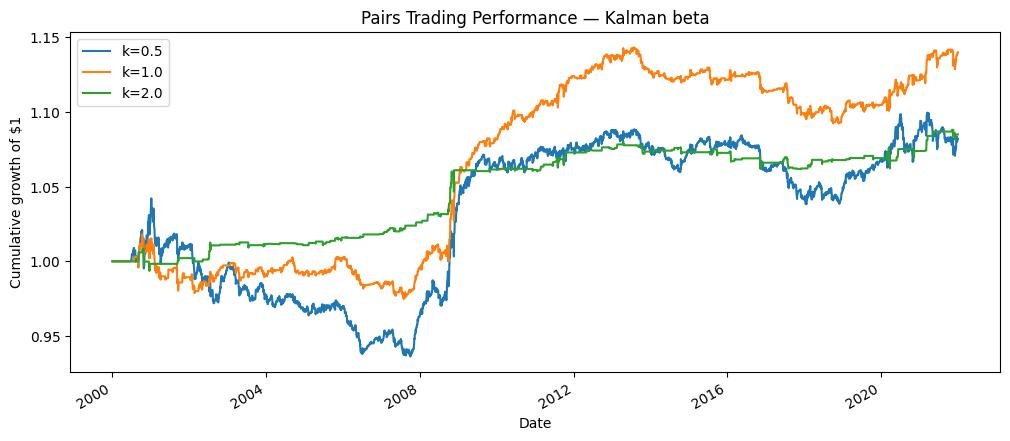

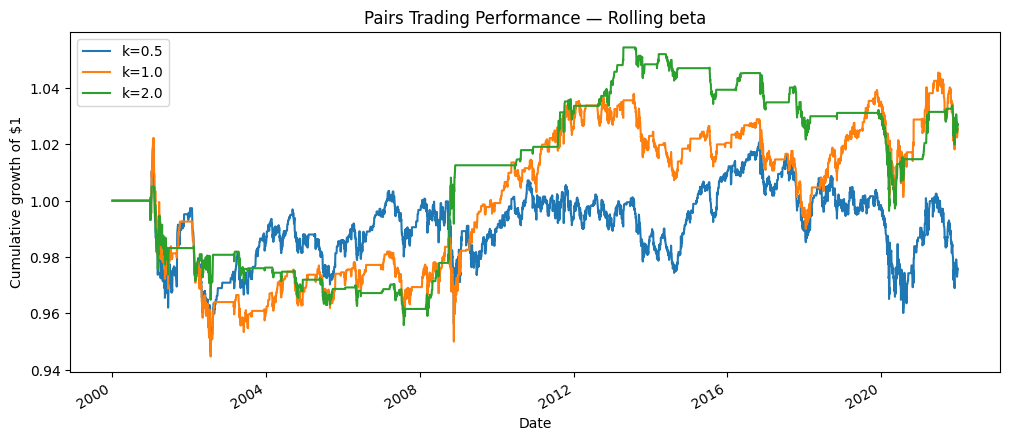

In [10]:
for method in ["Kalman", "Rolling"]:
    plt.figure()
    
    for k in k_list:
        equity_curves[(method, k)].plot(label=f"k={k}")
        
    plt.title(f"Pairs Trading Performance — {method} beta")
    
    plt.ylabel("Cumulative growth of $1")
    
    plt.legend()
    plt.show()


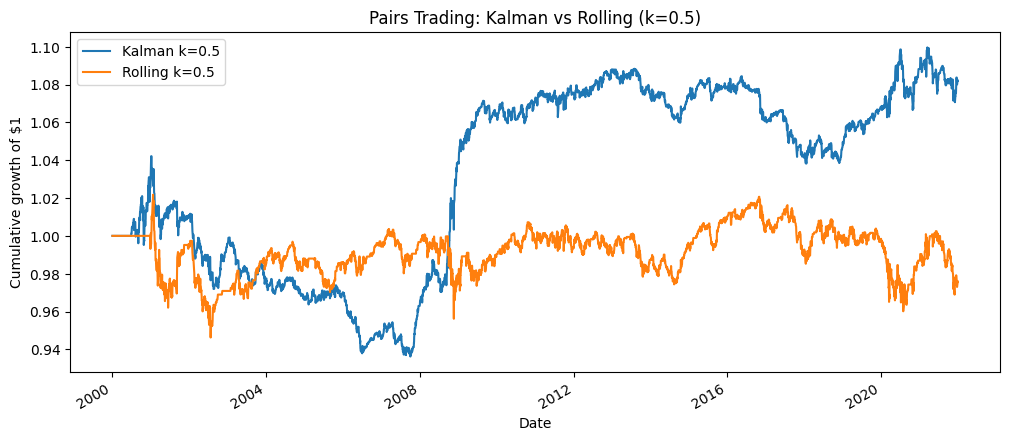

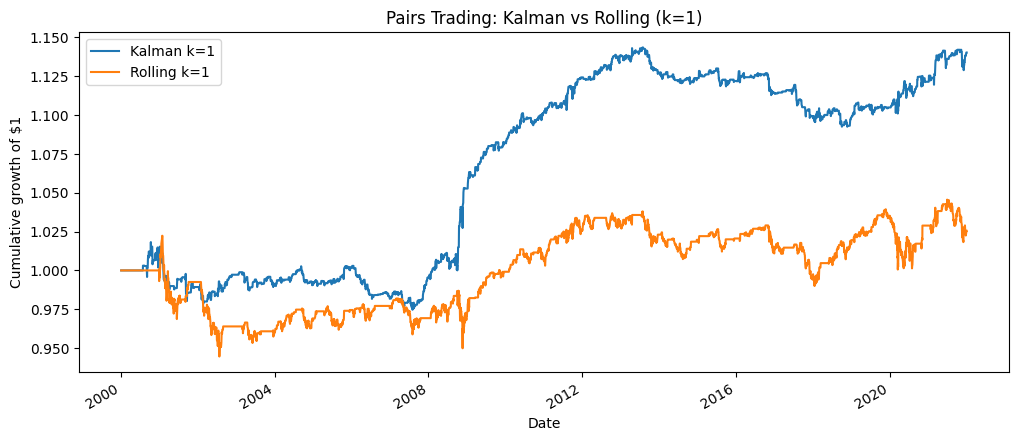

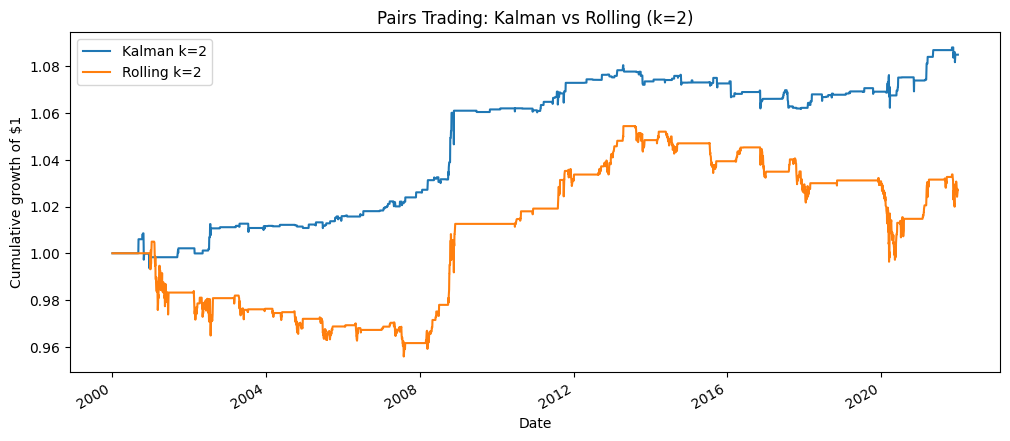

In [11]:
k_focus = 0.5

plt.figure()
equity_curves[("Kalman", k_focus)].plot(label=f"Kalman k={k_focus}")

equity_curves[("Rolling", k_focus)].plot(label=f"Rolling k={k_focus}")
plt.title("Pairs Trading: Kalman vs Rolling (k=0.5)")


plt.ylabel("Cumulative growth of $1")
plt.legend()
plt.show()


k_focus1 = 1

plt.figure()
equity_curves[("Kalman", k_focus1)].plot(label=f"Kalman k={k_focus1}")

equity_curves[("Rolling", k_focus1)].plot(label=f"Rolling k={k_focus1}")
plt.title("Pairs Trading: Kalman vs Rolling (k=1)")


plt.ylabel("Cumulative growth of $1")
plt.legend()
plt.show()


k_focus2 = 2

plt.figure()
equity_curves[("Kalman", k_focus2)].plot(label=f"Kalman k={k_focus2}")

equity_curves[("Rolling", k_focus2)].plot(label=f"Rolling k={k_focus2}")
plt.title("Pairs Trading: Kalman vs Rolling (k=2)")


plt.ylabel("Cumulative growth of $1")
plt.legend()
plt.show()


## 6. Summary Table (CAGR / Vol / Sharpe / MaxDD)

In [12]:
tbl = stats_df.copy()
tbl["CAGR"] = (tbl["CAGR"]*100).round(2)


tbl["Vol"] = (tbl["Vol"]*100).round(2)

tbl["Sharpe"] = tbl["Sharpe"].round(2)
tbl["MaxDD"] = (tbl["MaxDD"]*100).round(2)

tbl.rename(columns={"CAGR":"CAGR (%)","Vol":"Vol (%)","MaxDD":"Max DD (%)"}, inplace=True)
tbl

CAGR (%)  Vol (%)  Sharpe  Max DD (%)
Method  k                                         
Kalman  0.5      0.36     1.97    0.19      -10.16
        1.0      0.60     1.51    0.40       -4.46
        2.0      0.37     0.82    0.46       -1.74
Rolling 0.5     -0.11     2.12   -0.04       -7.38
        1.0      0.11     1.85    0.07       -7.59
        2.0      0.12     1.37    0.10       -5.50

## 7 Discussion
I compare rolling regression and Kalman filtering for estimating the dynamic hedge ratio in a pair trading strategy between SPY and DJIA. Rolling regression assumes a fixed window and produces a relatively smooth but lagged estimate of β. While this approach is simple and stable, it reacts slowly to structural changes in the relationship between the two ETFs. In contrast, the Kalman filter models β as a latent state following a random walk and updates it recursively as new information arrives. This adaptive structure allows the hedge ratio to respond more quickly to regime shifts.

Empirically, the Kalman filter generates a more responsive beta path and leads to a spread that mean-reverts more efficiently. As a result, the trading strategy based on Kalman filtering typically shows improved Sharpe ratio and faster recovery during volatile periods. Rolling regression may perform comparably in stable markets but tends to underperform during rapid market transitions due to estimation lag.

Overall, the Kalman filter provides a statistically principled and economically intuitive framework for dynamic hedge ratio estimation and appears more suitable for adaptive pair trading strategies.